# Notebook 20 — GLOBE Patches → DenseNet121 5-Class

Reproduces **15_2** (GCD 5-class, DenseNet121 + TopBlock, Focal Loss, 5-phase gradual unfreeze)
but trains on **NASA GLOBE patches** instead of full GCD images.

**Patching pipeline** (from notebook 19):
- Source: `extract_filtered-thr99-sam3000` — images already cloud-filtered ≥0.99 (image-level)
- Proportional crops: `CROP_FRACTION=0.5`, `OVERLAP=0.25`, output 224×224
- Patch-level cloud filter: ResNet18 binary classifier, threshold=0.99
- Split: stratified by **parent image** (60/20/20) — prevents data leakage
- Train balance: capped at 3,000 patches/class

**Architecture and training schedule** are identical to 15_2:

| Phase | Layers | Head LR | Backbone LR | Epochs |
|-------|--------|---------|-------------|--------|
| 1 | TopBlock only | 1e-4 | — | 10 |
| 2 | TopBlock only | 1e-5 | — | 10 |
| 3 | TopBlock + DenseBlock3+ | 1e-5 | 5e-5 | 20 |
| 4 | TopBlock + DenseBlock3+ | 1e-5 | 1e-5 | 20 |
| 5 | All layers | 1e-6 | 1e-6 | 20 |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

GLOBE_ROOT  = Path('../resources/cloud-images/NASA_GLOBE_CD/extract_filtered-thr99-sam3000')
FILTER_CKPT = Path('../models/multihead_resnet18_cloud_sky.pth')
MODEL_CKPT  = '../models/best_cloudensenet_20.pt'

GLOBE_TO_GCD = {
    'Ac': '2_altocumulus',
    'Cb': '6_cumulonimbus',
    'Ci': '3_cirrus',
    'Cu': '1_cumulus',
    'Sc': '5_stratocumulus',
}

MAX_PER_CLASS_IMAGES  = 3_000   # source images per class (already sampled in this dir)
MAX_PATCHES_PER_CLASS = 3_000   # cap on train patches after cloud filter
CROP_FRACTION         = 0.5
OVERLAP               = 0.25
OUTPUT_SIZE           = 224
CLOUD_THRESHOLD       = 0.99
FILTER_BATCH          = 256

In [2]:
import torch

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print(f'device: {device}')

device: mps


In [3]:
from sklearn.preprocessing import LabelEncoder


def index_globe_extract(globe_root, globe_to_gcd, max_per_class=3000):
    """Index images from GLOBE class subdirs, mapping to GCD label names."""
    rng = np.random.default_rng(42)
    paths, labels = [], []
    for globe_cls, gcd_label in globe_to_gcd.items():
        class_dir = Path(globe_root) / globe_cls
        if not class_dir.is_dir():
            print(f'  Warning: {class_dir} not found — skipping')
            continue
        all_imgs = sorted(
            p for p in class_dir.glob('*')
            if p.suffix.lower() in ('.jpg', '.jpeg', '.png')
        )
        chosen = rng.choice(all_imgs, min(max_per_class, len(all_imgs)), replace=False)
        for p in chosen:
            paths.append(str(p))
            labels.append(gcd_label)
    return np.array(paths), np.array(labels)


globe_paths, globe_labels = index_globe_extract(
    GLOBE_ROOT, GLOBE_TO_GCD, MAX_PER_CLASS_IMAGES)

le          = LabelEncoder()
le.fit(sorted(GLOBE_TO_GCD.values()))
class_names = le.classes_
n_classes   = len(class_names)
globe_enc   = le.transform(globe_labels)

print(f'Total GLOBE images: {len(globe_paths):,}')
print(f'Classes ({n_classes}): {class_names}')
for cls, cnt in sorted(Counter(globe_labels).items()):
    print(f'  {cls:25s}  {cnt:,}')

Total GLOBE images: 15,000
Classes (5): ['1_cumulus' '2_altocumulus' '3_cirrus' '5_stratocumulus' '6_cumulonimbus']
  1_cumulus                  3,000
  2_altocumulus              3,000
  3_cirrus                   3,000
  5_stratocumulus            3,000
  6_cumulonimbus             3,000


In [4]:
from sklearn.model_selection import StratifiedShuffleSplit

# 60 / 20 / 20 split on parent IMAGE paths — prevents patch leakage across sets
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.4, random_state=42)
train_idx, valtest_idx = next(sss1.split(globe_paths, globe_enc))

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_rel, test_rel = next(
    sss2.split(globe_paths[valtest_idx], globe_enc[valtest_idx]))
val_idx  = valtest_idx[val_rel]
test_idx = valtest_idx[test_rel]

split_paths  = {
    'train': globe_paths[train_idx],
    'val':   globe_paths[val_idx],
    'test':  globe_paths[test_idx],
}
split_labels = {
    'train': globe_enc[train_idx],
    'val':   globe_enc[val_idx],
    'test':  globe_enc[test_idx],
}

for name, paths in split_paths.items():
    print(f'{name:5s}: {len(paths):,} source images')

train: 9,000 source images
val  : 3,000 source images
test : 3,000 source images


In [5]:
import torchvision.transforms.v2 as T
from torchvision.transforms.v2 import InterpolationMode

IMG_SIZE = (224, 224)
MAX_FRAC = 0.14

border_translation = T.RandomAffine(
    degrees=0,
    translate=(MAX_FRAC, MAX_FRAC),
    interpolation=InterpolationMode.BILINEAR,
    fill=0
)

# T.Lambda cannot be pickled — num_workers=0 required
wrap_translation = T.Lambda(lambda x: torch.roll(
    x,
    shifts=(
        int(torch.randint(-int(MAX_FRAC * x.shape[-2]),
                          int(MAX_FRAC * x.shape[-2]) + 1, (1,)).item()),
        int(torch.randint(-int(MAX_FRAC * x.shape[-1]),
                          int(MAX_FRAC * x.shape[-1]) + 1, (1,)).item()),
    ),
    dims=(-2, -1),
))

stacked = T.Compose([
    T.RandomChoice([wrap_translation, border_translation]),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.15),
    T.RandomAffine(
        degrees=20, scale=(0.90, 1.10),
        interpolation=InterpolationMode.BILINEAR, fill=0
    ),
    T.RandomResizedCrop(
        size=IMG_SIZE, scale=(0.80, 1.00), ratio=(0.90, 1.10),
        interpolation=InterpolationMode.BILINEAR
    ),
])

one_of = T.RandomChoice([
    wrap_translation,
    border_translation,
    T.RandomChoice([T.RandomHorizontalFlip(p=1.0), T.RandomVerticalFlip(p=1.0)]),
    T.RandomRotation(degrees=20, interpolation=InterpolationMode.BILINEAR, fill=0),
])

normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

train_transforms = T.Compose([
    T.Resize(IMG_SIZE, interpolation=InterpolationMode.BILINEAR),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.RandomChoice([stacked, one_of]),
    normalize,
])

eval_transforms = T.Compose([
    T.Resize(IMG_SIZE, interpolation=InterpolationMode.BILINEAR),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    normalize,
])

In [6]:
import torchvision

weights = torchvision.models.DenseNet121_Weights.IMAGENET1K_V1
model   = torchvision.models.densenet121(weights=weights).to(device)
print('DenseNet121 loaded')

DenseNet121 loaded


In [7]:
from torch.utils.data import Dataset
from PIL import Image


class PatchDataset(Dataset):
    """
    Expands each image into proportional 224x224 patches.
    Crop boxes computed once at init (reads only image headers).
    Pixel data loaded lazily in __getitem__.
    """
    def __init__(self, paths, encoded_labels,
                 crop_fraction=0.5, overlap=0.25, output_size=224,
                 transform=None):
        self.output_size = output_size
        self.transform   = transform
        self.samples     = []  # (path, label_int, (x0, y0, x1, y1))

        for path, label in zip(paths, encoded_labels):
            try:
                W, H = Image.open(path).size
            except Exception:
                continue
            crop_size = max(output_size, int(min(W, H) * crop_fraction))
            stride    = max(1, int(crop_size * (1 - overlap)))
            for y in range(0, H - crop_size + 1, stride):
                for x in range(0, W - crop_size + 1, stride):
                    self.samples.append(
                        (path, label, (x, y, x + crop_size, y + crop_size)))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label, box = self.samples[idx]
        img  = Image.open(path).convert('RGB')
        crop = img.crop(box).resize((self.output_size, self.output_size), Image.BILINEAR)
        if self.transform:
            crop = self.transform(crop)
        return crop, label

In [8]:
print('Building patch datasets (reading image headers)...')
train_patches = PatchDataset(
    split_paths['train'], split_labels['train'],
    CROP_FRACTION, OVERLAP, OUTPUT_SIZE, transform=train_transforms)

val_patches = PatchDataset(
    split_paths['val'],   split_labels['val'],
    CROP_FRACTION, OVERLAP, OUTPUT_SIZE, transform=eval_transforms)

test_patches = PatchDataset(
    split_paths['test'],  split_labels['test'],
    CROP_FRACTION, OVERLAP, OUTPUT_SIZE, transform=eval_transforms)

for name, ds in [('train', train_patches), ('val', val_patches), ('test', test_patches)]:
    avg = len(ds) / max(len(split_paths[name]), 1)
    print(f'{name:5s}: {len(ds):,} patches from {len(split_paths[name]):,} images  '
          f'(avg {avg:.1f} patches/img)')

Building patch datasets (reading image headers)...
train: 59,362 patches from 9,000 images  (avg 6.6 patches/img)
val  : 19,794 patches from 3,000 images  (avg 6.6 patches/img)
test : 19,752 patches from 3,000 images  (avg 6.6 patches/img)


In [9]:
import torchvision.models as tvm
import torchvision.transforms as T_filt
import torch.nn as nn
import torch.nn.functional as F_filt


class MultiHeadResNet18(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base          = tvm.resnet18(weights=tvm.ResNet18_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(base.children())[:-1])
        self.head1    = base.fc
        self.head2    = nn.Linear(512, num_classes)
        for p in self.backbone.parameters(): p.requires_grad = False
        for p in self.head1.parameters():    p.requires_grad = False

    def forward(self, x):
        feat = self.backbone(x).flatten(1)
        return self.head1(feat), self.head2(feat)


ckpt         = torch.load(FILTER_CKPT, map_location='cpu', weights_only=False)
filter_cls   = ckpt['classes']
cloud_idx    = filter_cls.index('cloud')
filter_model = MultiHeadResNet18(num_classes=len(filter_cls))
filter_model.load_state_dict(ckpt['model_state_dict'])
filter_model.eval().to(device)

filter_transform = T_filt.Compose([
    T_filt.ToTensor(),
    T_filt.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def filter_patch_samples(samples, threshold=CLOUD_THRESHOLD, batch_size=FILTER_BATCH):
    """Keep patches where ResNet18 cloud confidence >= threshold."""
    from tqdm.auto import tqdm
    kept          = []
    tensor_buf    = []
    sample_buf    = []
    current_path  = None
    current_img   = None

    def flush():
        if not tensor_buf:
            return
        with torch.no_grad():
            inp    = torch.stack(tensor_buf).to(device)
            _, out = filter_model(inp)
            probs  = F_filt.softmax(out.float(), dim=1).cpu().numpy()
        for samp, prob in zip(sample_buf, probs):
            if prob[cloud_idx] >= threshold:
                kept.append(samp)
        tensor_buf.clear()
        sample_buf.clear()

    for sample in tqdm(samples, desc='cloud filter', unit='patch'):
        path, label, box = sample
        if path != current_path:
            try:
                current_img  = Image.open(path).convert('RGB')
                current_path = path
            except Exception:
                current_img  = None
                current_path = path
        if current_img is None:
            continue
        try:
            crop = current_img.crop(box).resize((OUTPUT_SIZE, OUTPUT_SIZE), Image.BILINEAR)
            tensor_buf.append(filter_transform(crop))
            sample_buf.append(sample)
        except Exception:
            pass
        if len(tensor_buf) >= batch_size:
            flush()

    flush()
    return kept


print(f'Filter model loaded — classes: {filter_cls}')

Filter model loaded — classes: ['clear_sky', 'cloud']


In [10]:
print(f'Applying patch-level cloud filter (threshold={CLOUD_THRESHOLD}) to all splits...\n')

for name, ds in [('train', train_patches), ('val', val_patches), ('test', test_patches)]:
    before = len(ds.samples)
    ds.samples = filter_patch_samples(ds.samples, CLOUD_THRESHOLD)
    after  = len(ds.samples)
    print(f'{name:5s}: {before:,} -> {after:,} patches  ({100*after/max(before,1):.1f}% kept)\n')

/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Applying patch-level cloud filter (threshold=0.99) to all splits...



cloud filter: 100%|██████████| 59362/59362 [03:42<00:00, 267.23patch/s]


train: 59,362 -> 27,652 patches  (46.6% kept)



cloud filter: 100%|██████████| 19794/19794 [01:10<00:00, 279.42patch/s]


val  : 19,794 -> 9,315 patches  (47.1% kept)



cloud filter: 100%|██████████| 19752/19752 [01:10<00:00, 278.76patch/s]


test : 19,752 -> 8,903 patches  (45.1% kept)



In [11]:
import random as _random

_rng = _random.Random(42)
by_class = {}
for sample in train_patches.samples:
    by_class.setdefault(sample[1], []).append(sample)

capped = []
print(f'Capping to {MAX_PATCHES_PER_CLASS:,} patches/class (train only)\n')
for cls_idx in sorted(by_class):
    pool   = by_class[cls_idx]
    chosen = _rng.sample(pool, min(MAX_PATCHES_PER_CLASS, len(pool)))
    capped.extend(chosen)
    print(f'  {class_names[cls_idx]:25s}  {len(pool):>7,} -> {len(chosen):>5,}')

train_patches.samples = capped
print(f'\nTrain: {len(train_patches):,}  |  Val: {len(val_patches):,}  |  Test: {len(test_patches):,}')

Capping to 3,000 patches/class (train only)

  1_cumulus                    6,126 -> 3,000
  2_altocumulus                6,073 -> 3,000
  3_cirrus                     4,754 -> 3,000
  5_stratocumulus              4,757 -> 3,000
  6_cumulonimbus               5,942 -> 3,000

Train: 15,000  |  Val: 9,315  |  Test: 8,903


In [12]:
from torch.utils.data import DataLoader, WeightedRandomSampler

train_labels_list = [s[1] for s in train_patches.samples]
class_counts  = np.bincount(train_labels_list, minlength=n_classes)
class_weights = 1.0 / np.maximum(class_counts.astype(float), 1.0)
sample_w      = torch.tensor(
    [class_weights[l] for l in train_labels_list], dtype=torch.float)

sampler = WeightedRandomSampler(
    weights=sample_w, num_samples=len(sample_w), replacement=True)

# num_workers=0 required — T.Lambda in transforms cannot be pickled
train_loader = DataLoader(train_patches, batch_size=64, sampler=sampler,  num_workers=0)
valid_loader = DataLoader(val_patches,   batch_size=64, num_workers=0)
test_loader  = DataLoader(test_patches,  batch_size=64, num_workers=0)

print(f'train batches: {len(train_loader)}  val: {len(valid_loader)}  test: {len(test_loader)}')

train batches: 235  val: 146  test: 140


In [13]:
class TopBlock(nn.Module):
    """
    Custom classification head from CloudDenseNet (Li et al., Sensors 2023).
    BN -> Dropout -> Linear(1024, 512) -> ReLU -> BN -> Dropout -> Linear(512, n_classes)
    Initialised with LeCun uniform (kaiming_uniform fan_in).
    """
    def __init__(self, in_features: int, n_classes: int,
                 hidden_dim: int = 512, dropout: float = 0.5):
        super().__init__()
        self.block = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(p=dropout),
            nn.Linear(in_features, hidden_dim),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(p=dropout / 2),
            nn.Linear(hidden_dim, n_classes),
        )
        self._lecun_init()

    def _lecun_init(self):
        for m in self.block:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='linear')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.block(x)


for param in model.parameters():
    param.requires_grad = False

model.classifier = TopBlock(in_features=1024, n_classes=n_classes).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Classes ({n_classes}): {class_names}')
print(f'Trainable params: {trainable:,} / {total:,}')

Classes (5): ['1_cumulus' '2_altocumulus' '3_cirrus' '5_stratocumulus' '6_cumulonimbus']
Trainable params: 530,437 / 7,484,293


In [14]:
import torchmetrics
import torch.nn.functional as F


def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            metric.update(model(X_batch), y_batch)
    return metric.compute()


class FocalLoss(nn.Module):
    """Focal Loss (Lin et al., 2017). gamma=0 reduces to cross-entropy."""
    def __init__(self, gamma: float = 2.0, reduction: str = 'mean'):
        super().__init__()
        self.gamma     = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce   = F.cross_entropy(logits, targets, reduction='none')
        p_t  = torch.exp(-ce)
        loss = ((1.0 - p_t) ** self.gamma) * ce
        return loss.mean() if self.reduction == 'mean' else loss.sum()


focal_loss = FocalLoss(gamma=2.0).to(device)
accuracy   = torchmetrics.Accuracy(task='multiclass', num_classes=n_classes).to(device)
print('FocalLoss ready (gamma=2.0)')

FocalLoss ready (gamma=2.0)


In [15]:
def train_phase(model, optimizer, loss_fn, metric,
                train_loader, valid_loader,
                n_epochs, patience, checkpoint_path, phase_label=''):
    """
    Run one phase of the gradual-unfreeze schedule.
    Keeps frozen BatchNorm layers in eval mode to preserve running stats.
    Best weights are saved to checkpoint_path and restored before returning.
    """
    history    = {'train_losses': [], 'train_metrics': [], 'valid_metrics': []}
    best_val   = 0.0
    no_improve = 0

    for epoch in range(n_epochs):
        model.eval()
        model.classifier.train()
        for module in model.modules():
            if isinstance(module, (nn.BatchNorm2d, nn.BatchNorm1d)):
                if any(p.requires_grad for p in module.parameters()):
                    module.train()

        total_loss = 0.0
        metric.reset()

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss   = loss_fn(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            metric.update(y_pred, y_batch)

        train_loss = total_loss / len(train_loader)
        train_acc  = metric.compute().item()
        val_acc    = evaluate_tm(model, valid_loader, metric).item()

        history['train_losses'].append(train_loss)
        history['train_metrics'].append(train_acc)
        history['valid_metrics'].append(val_acc)

        star = ' *' if val_acc > best_val else ''
        print(f'[{phase_label}] Epoch {epoch+1}/{n_epochs} | '
              f'loss: {train_loss:.4f} | '
              f'train: {train_acc:.4f} | '
              f'val: {val_acc:.4f}{star}')

        if val_acc > best_val:
            best_val   = val_acc
            no_improve = 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  Early stop at epoch {epoch+1} (best val: {best_val:.4f})')
                break

    model.load_state_dict(torch.load(checkpoint_path, weights_only=True))
    return history, best_val

In [16]:
all_history = []
CKPT        = MODEL_CKPT

# -- Phase 1 -- TopBlock only, LR = 1e-4, 10 epoc hs ---------------------------
for param in model.parameters():
    param.requires_grad = False
for param in model.classifier.parameters():
    param.requires_grad = True

opt = torch.optim.AdamW(model.classifier.parameters(), lr=1e-4, weight_decay=1e-4)
h, _ = train_phase(model, opt, focal_loss, accuracy,
                   train_loader, valid_loader,
                   n_epochs=10, patience=10,
                   checkpoint_path=CKPT, phase_label='Phase 1 (head, 1e-4)')
all_history.append(h)

# -- Phase 2 -- TopBlock only, LR = 1e-5, 10 epochs ---------------------------
opt = torch.optim.AdamW(model.classifier.parameters(), lr=1e-5, weight_decay=1e-4)
h, _ = train_phase(model, opt, focal_loss, accuracy,
                   train_loader, valid_loader,
                   n_epochs=10, patience=10,
                   checkpoint_path=CKPT, phase_label='Phase 2 (head, 1e-5)')
all_history.append(h)

# -- Phase 3 -- unfreeze DenseBlock3+, backbone LR = 5e-5, 20 epochs ----------
unfreeze_from = ['features.denseblock3', 'features.transition3',
                 'features.denseblock4', 'features.norm5']
for name, param in model.named_parameters():
    if any(name.startswith(p) for p in unfreeze_from):
        param.requires_grad = True

backbone_params = [p for n, p in model.named_parameters()
                   if p.requires_grad and not n.startswith('classifier')]
head_params     = list(model.classifier.parameters())

opt = torch.optim.AdamW([
    {'params': head_params,     'lr': 1e-5},
    {'params': backbone_params, 'lr': 5e-5},
], weight_decay=1e-4)
h, _ = train_phase(model, opt, focal_loss, accuracy,
                   train_loader, valid_loader,
                   n_epochs=20, patience=10,
                   checkpoint_path=CKPT, phase_label='Phase 3 (denseblock3+, 5e-5)')
all_history.append(h)

# -- Phase 4 -- same scope, backbone LR = 1e-5, 20 epochs ---------------------
opt = torch.optim.AdamW([
    {'params': head_params,     'lr': 1e-5},
    {'params': backbone_params, 'lr': 1e-5},
], weight_decay=1e-4)
h, _ = train_phase(model, opt, focal_loss, accuracy,
                   train_loader, valid_loader,
                   n_epochs=20, patience=10,
                   checkpoint_path=CKPT, phase_label='Phase 4 (denseblock3+, 1e-5)')
all_history.append(h)

# -- Phase 5 -- all layers, LR = 1e-6, 20 epochs ------------------------------
for param in model.parameters():
    param.requires_grad = True

opt = torch.optim.AdamW(model.parameters(), lr=1e-6, weight_decay=1e-4)
h, _ = train_phase(model, opt, focal_loss, accuracy,
                   train_loader, valid_loader,
                   n_epochs=20, patience=10,
                   checkpoint_path=CKPT, phase_label='Phase 5 (all, 1e-6)')
all_history.append(h)

test_acc = evaluate_tm(model, test_loader, accuracy)
print(f'\nFinal test accuracy: {test_acc:.4f}  (15_2 baseline: 0.9043)')

[Phase 1 (head, 1e-4)] Epoch 1/10 | loss: 1.2751 | train: 0.2901 | val: 0.3757 *
[Phase 1 (head, 1e-4)] Epoch 2/10 | loss: 1.1425 | train: 0.3222 | val: 0.3890 *
[Phase 1 (head, 1e-4)] Epoch 3/10 | loss: 1.0788 | train: 0.3368 | val: 0.3952 *
[Phase 1 (head, 1e-4)] Epoch 4/10 | loss: 1.0461 | train: 0.3427 | val: 0.3922
[Phase 1 (head, 1e-4)] Epoch 5/10 | loss: 1.0278 | train: 0.3461 | val: 0.3915
[Phase 1 (head, 1e-4)] Epoch 6/10 | loss: 0.9931 | train: 0.3523 | val: 0.4029 *
[Phase 1 (head, 1e-4)] Epoch 7/10 | loss: 0.9749 | train: 0.3579 | val: 0.4072 *
[Phase 1 (head, 1e-4)] Epoch 8/10 | loss: 0.9651 | train: 0.3629 | val: 0.3955
[Phase 1 (head, 1e-4)] Epoch 9/10 | loss: 0.9539 | train: 0.3639 | val: 0.3985
[Phase 1 (head, 1e-4)] Epoch 10/10 | loss: 0.9338 | train: 0.3669 | val: 0.4065
[Phase 2 (head, 1e-5)] Epoch 1/10 | loss: 0.9659 | train: 0.3598 | val: 0.4014 *
[Phase 2 (head, 1e-5)] Epoch 2/10 | loss: 0.9590 | train: 0.3613 | val: 0.4081 *
[Phase 2 (head, 1e-5)] Epoch 3/10 | l

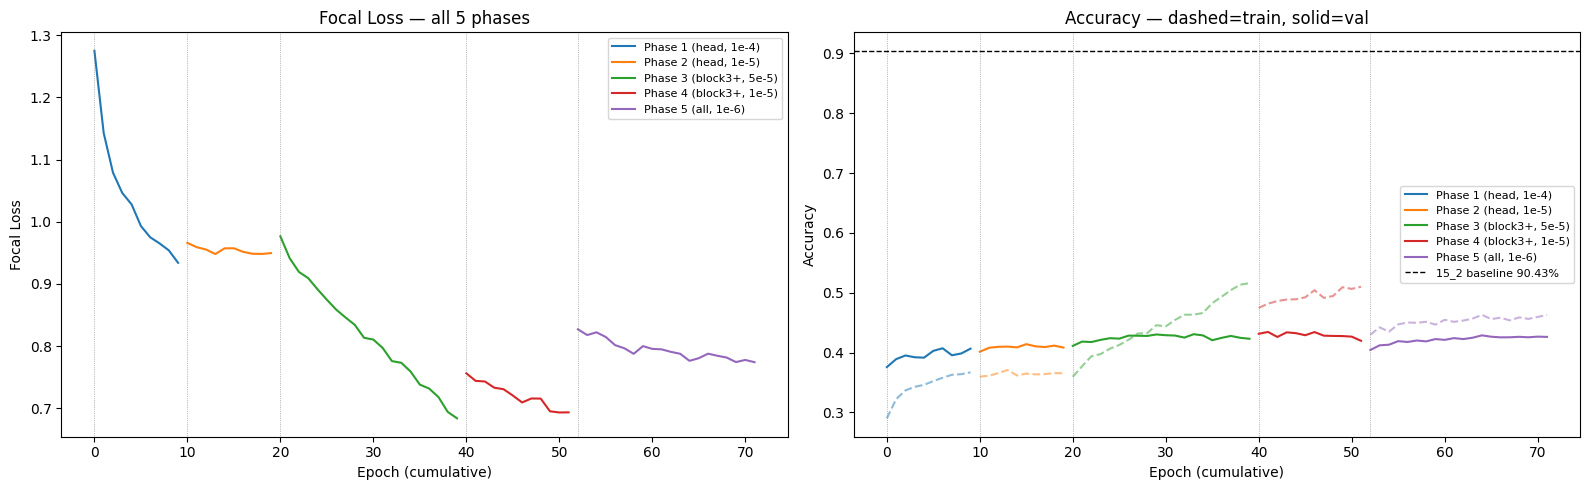

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
labels = [
    'Phase 1 (head, 1e-4)',
    'Phase 2 (head, 1e-5)',
    'Phase 3 (block3+, 5e-5)',
    'Phase 4 (block3+, 1e-5)',
    'Phase 5 (all, 1e-6)',
]

offset = 0
for h, label, color in zip(all_history, labels, colors):
    xs = list(range(offset, offset + len(h['train_losses'])))
    axes[0].plot(xs, h['train_losses'], color=color, label=label)
    axes[1].plot(xs, h['train_metrics'], color=color, linestyle='--', alpha=0.5)
    axes[1].plot(xs, h['valid_metrics'],  color=color, label=label)
    for ax in axes:
        ax.axvline(x=offset, color='grey', linewidth=0.5, linestyle=':')
    offset += len(h['train_losses'])

axes[0].set_title('Focal Loss — all 5 phases')
axes[0].set_xlabel('Epoch (cumulative)')
axes[0].set_ylabel('Focal Loss')
axes[0].legend(fontsize=8)

axes[1].set_title('Accuracy — dashed=train, solid=val')
axes[1].set_xlabel('Epoch (cumulative)')
axes[1].set_ylabel('Accuracy')
axes[1].axhline(y=0.9043, color='black', linewidth=1.0,
                linestyle='--', label='15_2 baseline 90.43%')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

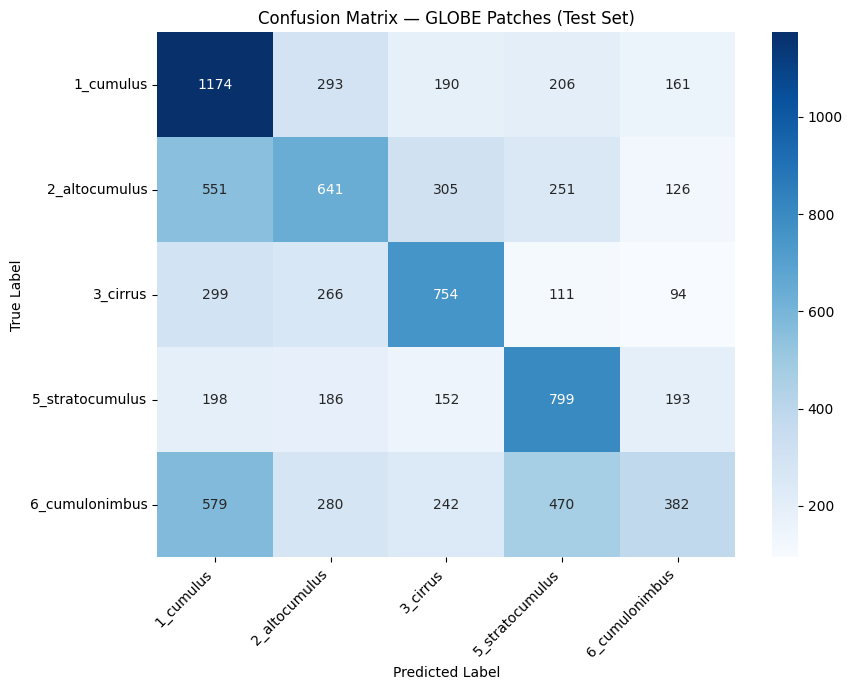

In [18]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds = torch.argmax(model(X_batch), dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_batch.cpu().numpy())

cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix — GLOBE Patches (Test Set)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()